In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42) # reproducibility

# Générer N échantillons aléatoirs depuis la distribution de Poisson avec une moyenne lambda
lambda_value = 10
N = 10000
DataPopulation = np.random.poisson(lam = lambda_value, size = N)

# Obtenir une sous population de n = 30 échantillons depuis Datapopulation
n = 200
DataSample = np.random.choice(DataPopulation, size=n,replace=False)

# Calculer la moyenne et la variance des  deux vecteurs
mean_population = np.mean(DataPopulation)
std_population = np.std(DataPopulation)

mean_sample = np.mean(DataSample)
std_sample = np.std(DataSample)

# Résultats
print(f"Moyenne population {mean_population}")
print(f"Variance population {std_population}")

print(f"Moyenne echantillon {mean_sample}")
print(f"Variance echantillon {std_sample}")

Moyenne population 10.0186
Variance population 3.144813832327758
Moyenne echantillon 10.17
Variance echantillon 2.8828978476526013


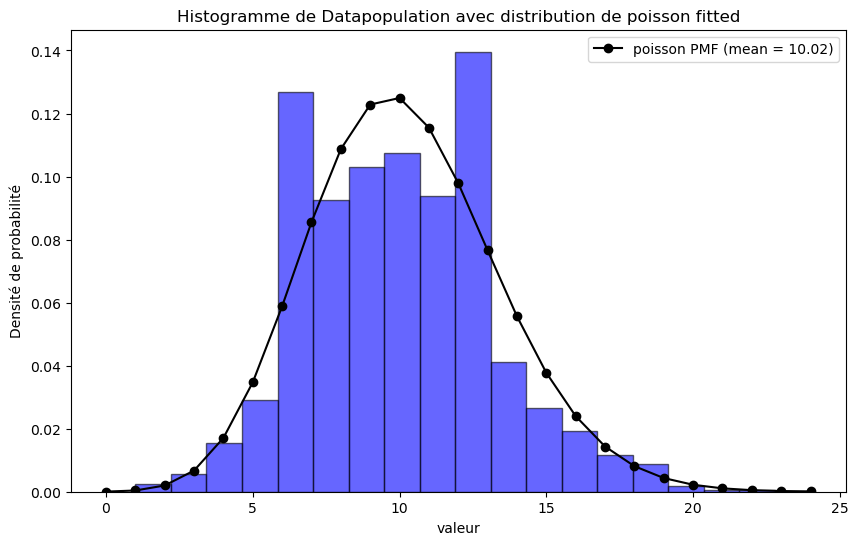

In [25]:
from scipy.stats import poisson

#Hist de datapop
plt.figure(figsize=(10,6))
counts, bins, _ = plt.hist(DataPopulation, bins=19, color='blue', edgecolor='black', alpha=0.6, density=True)

# Distribution de Poisson qui fit au mieux la moyenne des échantillons
x = np.arange(0, bins[-1]+1)
pmf_values = poisson.pmf(x, mu= mean_sample)
plt.plot(x, pmf_values, 'k-', marker='o', label = f"poisson PMF (mean = {mean_population:.2f})")

#labels
plt.xlabel('valeur')
plt.ylabel('Densité de probabilité')
plt.title('Histogramme de Datapopulation avec distribution de poisson fitted')

plt.legend()
plt.show()

In [ ]:
# Debug -> J'avais pas mis density = True dans plt.hist
print(f"{np.mean(pmf_values):.2f}")
print(np.mean(DataPopulation))

print(bins.shape)
print(x.shape)

0.04
10.0186
(20,)
(25,)


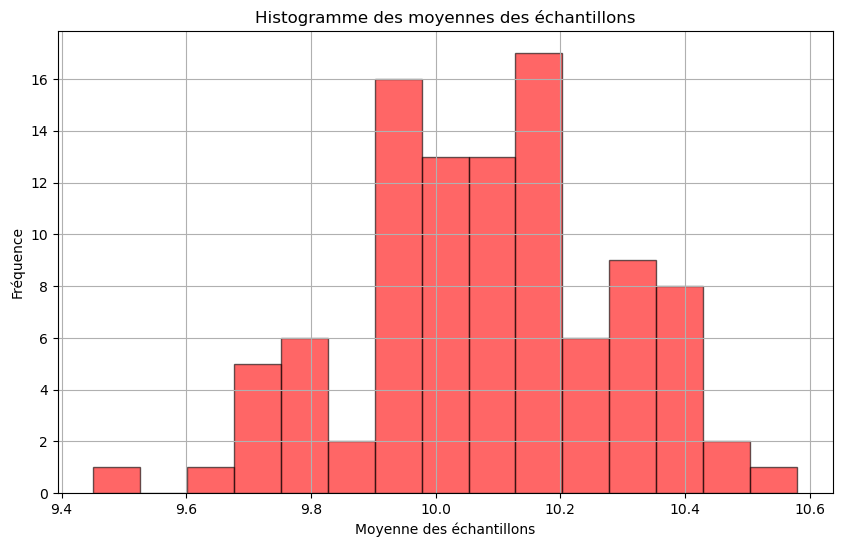

In [43]:
#np.random.seed(42) # reproducibility

# Générer N échantillons aléatoirs depuis la distribution de Poisson avec une moyenne lambda
lambda_value = 10
N = 10000
DataPopulation = np.random.poisson(lam = lambda_value, size = N)

# Obtenir une sous population de n = 30 échantillons depuis Datapopulation
lambda_value = 10
n = 200
m=100 # nb  d echantillons a prendre

# Initialisation des array pour stocker les valeurs de moyenne et de variance des  echantillons
SampleMeans = np.zeros(m)
SampleSTD = np.zeros(m)

for i in range(m):
    DataSample = np.random.choice(DataPopulation, size = n, replace= False)
    SampleMeans[i]=np.mean(DataSample)
    SampleSTD[i]=np.std(DataSample)

# plot
plt.figure(figsize=(10,6))
plt.hist(SampleMeans, bins = 15, color='red',edgecolor='black', alpha =0.6)
plt.title('Histogramme des moyennes des échantillons')
plt.xlabel('Moyenne des échantillons')
plt.ylabel('Fréquence')
plt.grid()
plt.show()

In [44]:
print(np.mean(SampleMeans))
print(np.std(SampleMeans))

10.08475
0.20473931596056477


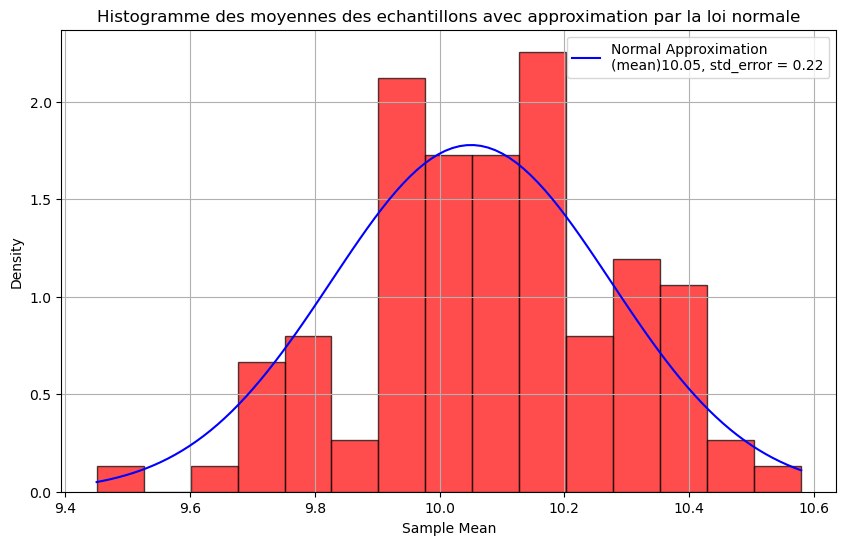

In [48]:
from scipy.stats import norm

mean_population = np.mean(DataPopulation)
std_population = np.std(DataPopulation)

# Calculer la variance des moyennes des  echantillons ( Standard error of the mean )
std_error = std_population/np.sqrt(n)

# Génération de la distribution normale qui approche la distribution des moyennes des echantillons
x = np.linspace(min(SampleMeans), max(SampleMeans), 100)
normal_approximation = norm.pdf(x, loc = mean_population, scale=std_error)

# Tracer hist de samplemeans
plt.figure(figsize=(10,6))
plt.hist(SampleMeans, bins = 15, color='red', edgecolor='black', alpha=0.7, density=True)

# Tracé de la loi normale approx
plt.plot(x, normal_approximation,'b',label=f'Normal Approximation\n(mean){mean_population:.2f}, std_error = {std_error:.2f}')

plt.xlabel('Sample Mean')
plt.ylabel('Density')
plt.title('Histogramme des moyennes des echantillons avec approximation par la loi normale')

plt.legend()
plt.grid()
plt.show()
